# Comparación de 3 arquitecturas (EfficientNetB0, ResNet50, MobileNetV3Small)

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import pandas as pd
import seaborn as sns

2025-08-25 19:13:09.976615: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-25 19:13:09.997625: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-25 19:13:10.124710: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-25 19:13:10.124743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-25 19:13:10.151202: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 15
FINE_TUNING_EPOCHS = 10
LEARNING_RATE_INITIAL = 0.001
LEARNING_RATE_FINE = 0.0001

DATA_DIR = "../datasets/fondo_blanco"

print(f"📊 Configuración:")
print(f"   - Tamaño de imagen: {IMG_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Épocas iniciales: {INITIAL_EPOCHS}")
print(f"   - Épocas fine-tuning: {FINE_TUNING_EPOCHS}")
print(f"   - Directorio de datos: {DATA_DIR}")

📊 Configuración:
   - Tamaño de imagen: (224, 224)
   - Batch size: 32
   - Épocas iniciales: 15
   - Épocas fine-tuning: 10
   - Directorio de datos: ../datasets/fondo_blanco


## Preprocesamiento

In [4]:
def load_and_preprocess_data(data_dir, img_size=(224, 224)):
    """Carga y preprocesa imágenes desde el directorio de datos"""
    if not os.path.exists(data_dir):
        raise ValueError(f"El directorio {data_dir} no existe")
        
    images = []
    labels = []
    
    classes = [d for d in sorted(os.listdir(data_dir)) 
              if os.path.isdir(os.path.join(data_dir, d))]
    
    if not classes:
        raise ValueError(f"No se encontraron subdirectorios (clases) en {data_dir}")
    
    print(f"🔍 Encontradas {len(classes)} clases: {classes}")
    
    total_images = 0
    for idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"   📁 Procesando clase '{class_name}': {len(image_files)} imágenes")
        
        for img_name in image_files:
            img_path = os.path.join(class_dir, img_name)
            try:
                img = tf.keras.preprocessing.image.load_img(
                    img_path,
                    target_size=img_size
                )
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                
                images.append(img_array)
                labels.append(idx)
                total_images += 1

            except Exception as e:
                print(f"   ⚠️  Error procesando {img_path}: {str(e)}")
    
    if total_images == 0:
        raise ValueError("No se pudieron cargar imágenes del directorio")
        
    print(f"\n✅ Total de imágenes cargadas: {total_images}")
    
    X = np.array(images)
    y = np.array(labels)

    print(f"�� Forma del array X: {X.shape}")
    print(f"�� Forma del array y: {y.shape}")
    
    y = tf.keras.utils.to_categorical(y, num_classes=len(classes))
    
    # División del dataset
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    
    print(f"\n📊 División del dataset completada:")
    print(f"   - Train: {X_train.shape[0]} muestras")
    print(f"   - Validación: {X_val.shape[0]} muestras")
    print(f"   - Test: {X_test.shape[0]} muestras")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, classes

def create_data_augmentation():
    """Crea capas de data augmentation avanzado"""
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
        tf.keras.layers.GaussianNoise(0.1),
    ])

def create_datasets(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, preprocess_func):
    """Crea tf.data.Dataset con augmentation y optimización"""
    
    data_augmentation = create_data_augmentation()
    
    def process_train_data(image, label):
        image = tf.cast(image, tf.float32)
        image = data_augmentation(image, training=True)
        image = preprocess_func(image)
        return image, label
    
    def process_val_test_data(image, label):
        image = tf.cast(image, tf.float32)
        image = preprocess_func(image)
        return image, label
        
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    
    train_ds = train_ds.map(process_train_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    val_ds = val_ds.map(process_val_test_data, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    test_ds = test_ds.map(process_val_test_data, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds, test_ds

# Cargar datos
X_train, X_val, X_test, y_train, y_val, y_test, classes = load_and_preprocess_data(DATA_DIR, IMG_SIZE)

🔍 Encontradas 19 clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']
   📁 Procesando clase 'A': 102 imágenes
   📁 Procesando clase 'B': 95 imágenes
   📁 Procesando clase 'C': 98 imágenes
   📁 Procesando clase 'D': 102 imágenes
   📁 Procesando clase 'E': 103 imágenes
   📁 Procesando clase 'F': 105 imágenes
   📁 Procesando clase 'G': 108 imágenes
   📁 Procesando clase 'I': 113 imágenes
   📁 Procesando clase 'K': 108 imágenes
   📁 Procesando clase 'L': 112 imágenes
   📁 Procesando clase 'M': 114 imágenes
   📁 Procesando clase 'N': 111 imágenes
   📁 Procesando clase 'O': 97 imágenes
   📁 Procesando clase 'P': 110 imágenes
   📁 Procesando clase 'Q': 120 imágenes
   📁 Procesando clase 'R': 90 imágenes
   📁 Procesando clase 'S': 100 imágenes
   📁 Procesando clase 'T': 102 imágenes
   📁 Procesando clase 'U': 108 imágenes

✅ Total de imágenes cargadas: 1998
�� Forma del array X: (1998, 224, 224, 3)
�� Forma del array y: (1998,)

📊 División del

## EfficientNetB0

Procesa imágenes en escala de grises

In [5]:
def create_efficientnet_model(input_shape, num_classes):
    """Crea un modelo basado en EfficientNetB0 con transfer learning"""
    print("🏗️  Creando modelo EfficientNetB0...")
    
    # Usar EfficientNetB0 sin weights pre-entrenados para evitar conflictos
    base_model = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights=None  # Sin weights pre-entrenados
    )
    
    # Congelar base model inicialmente
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_INITIAL),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Modelo EfficientNetB0 creado:")
    print(f"   - Parámetros totales: {model.count_params():,}")
    print(f"   - Parámetros entrenables: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
    
    return model, base_model

## ResNet50

In [6]:
def create_resnet_model(input_shape, num_classes):
    """Crea un modelo basado en ResNet50 con transfer learning"""
    print("Modelo ResNet50...")
    
    base_model = ResNet50(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Congelar base model inicialmente
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_INITIAL),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Modelo ResNet50 creado:")
    print(f"   - Parámetros totales: {model.count_params():,}")
    print(f"   - Parámetros entrenables: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
    
    return model, base_model

## MobileNetV3

In [7]:
def create_mobilenetv3_model(input_shape, num_classes):
    """Crea un modelo basado en MobileNetV3 con transfer learning"""
    print("Modelo MobileNetV3...")
    
    base_model = MobileNetV3Small(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Congelar base model inicialmente
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_INITIAL),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"✅ Modelo MobileNetV3 creado:")
    print(f"   - Parámetros totales: {model.count_params():,}")
    print(f"   - Parámetros entrenables: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
    
    return model, base_model

# Entrenamiento Unificado

In [8]:
def train_model_comparison(model, base_model, train_ds, val_ds, test_ds, 
                          model_name, initial_epochs=15, fine_tuning_epochs=10):
    """Entrena el modelo con estrategia de dos fases y retorna métricas"""
    
    print(f"\n🚀 Entrenando {model_name}...")
    print("=" * 50)
    
    # Callbacks para optimización
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        )
    ]
    
    # Fase 1: Entrenamiento inicial con base model congelado
    print("Fase 1: Entrenamiento inicial (base model congelado)")
    start_time = time.time()
    
    history_initial = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=initial_epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    initial_time = time.time() - start_time
    
    # Fase 2: Fine-tuning
    print(f"\n🔧 Fase 2: Fine-tuning (descongelar capas del base model)")
    
    # Descongelar últimas capas del base model
    base_model.trainable = True
    
    # Para EfficientNetB0: descongelar últimas 50 capas
    if "EfficientNet" in model_name:
        for layer in base_model.layers[:-50]:
            layer.trainable = False
    # Para ResNet50: descongelar últimas 30 capas
    elif "ResNet" in model_name:
        for layer in base_model.layers[:-30]:
            layer.trainable = False
    # Para MobileNetV3: descongelar últimas 40 capas
    else:
        for layer in base_model.layers[:-40]:
            layer.trainable = False
    
    # Recompilar con learning rate menor
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE_FINE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    start_time = time.time()
    
    fine_tuning_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=initial_epochs + fine_tuning_epochs,
        initial_epoch=initial_epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    fine_tuning_time = time.time() - start_time
    
    # Evaluación final
    print(f"\nEvaluando {model_name} en conjunto de test...")
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    
    # Combinar historiales
    acc = history_initial.history['accuracy'] + fine_tuning_history.history['accuracy']
    val_acc = history_initial.history['val_accuracy'] + fine_tuning_history.history['val_accuracy']
    loss = history_initial.history['loss'] + fine_tuning_history.history['loss']
    val_loss = history_initial.history['val_loss'] + fine_tuning_history.history['val_loss']
    
    # Métricas finales
    final_train_acc = acc[-1]
    final_val_acc = val_acc[-1]
    final_test_acc = test_accuracy
    
    # Tiempo total
    total_time = initial_time + fine_tuning_time
    
    print(f"\n{model_name} - Entrenamiento completado:")
    print(f"   - Accuracy final (train): {final_train_acc:.4f}")
    print(f"   - Accuracy final (val): {final_val_acc:.4f}")
    print(f"   - Accuracy final (test): {final_test_acc:.4f}")
    print(f"   - Tiempo total: {total_time:.2f} segundos")
    
    # Guardar modelo
    model_filename = f"modelo_{model_name.lower().replace(' ', '_')}.h5"
    model.save(model_filename)
    print(f"   - Modelo guardado: {model_filename}")
    
    return {
        'model_name': model_name,
        'final_train_acc': final_train_acc,
        'final_val_acc': final_val_acc,
        'final_test_acc': final_test_acc,
        'total_time': total_time,
        'history': {
            'accuracy': acc,
            'val_accuracy': val_acc,
            'loss': loss,
            'val_loss': val_loss
        }
    }

# Entrenar las 3 arquitecturas

In [9]:
print("COMPARACIÓN DE 3 ARQUITECTURAS ALTERNATIVAS")
print("=" * 60)

input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
num_classes = len(classes)

architectures = [
    {
        'name': 'EfficientNetB0',
        'create_func': create_efficientnet_model,
        'preprocess_func': tf.keras.applications.efficientnet.preprocess_input
    },
    {
        'name': 'ResNet50',
        'create_func': create_resnet_model,
        'preprocess_func': tf.keras.applications.resnet.preprocess_input
    },
    {
        'name': 'MobileNetV3',
        'create_func': create_mobilenetv3_model,
        'preprocess_func': tf.keras.applications.mobilenet_v3.preprocess_input
    }
]

# Entrenar y evaluar cada arquitectura
results = []

for arch in architectures:
    print(f"\n{'='*60}")
    print(f"PROBANDO ARQUITECTURA: {arch['name']}")
    print(f"{'='*60}")
    
    # Crear datasets específicos para esta arquitectura
    train_ds, val_ds, test_ds = create_datasets(
        X_train, X_val, X_test, y_train, y_val, y_test, 
        BATCH_SIZE, arch['preprocess_func']
    )
    
    # Crear y entrenar modelo
    model, base_model = arch['create_func'](input_shape, num_classes)
    
    # Entrenar modelo
    result = train_model_comparison(
        model, base_model, train_ds, val_ds, test_ds,
        arch['name'], INITIAL_EPOCHS, FINE_TUNING_EPOCHS
    )
    
    results.append(result)
    
    # Limpiar memoria
    del model, base_model
    tf.keras.backend.clear_session()

print(f"\n{'='*60}")
print("TODAS LAS ARQUITECTURAS ENTRENADAS EXITOSAMENTE")
print(f"{'='*60}")

COMPARACIÓN DE 3 ARQUITECTURAS ALTERNATIVAS

PROBANDO ARQUITECTURA: EfficientNetB0


2025-08-25 19:14:50.683493: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-25 19:14:50.688287: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


🏗️  Creando modelo EfficientNetB0...
Modelo EfficientNetB0 creado:
   - Parámetros totales: 4,841,654
   - Parámetros entrenables: 792,083

🚀 Entrenando EfficientNetB0...
Fase 1: Entrenamiento inicial (base model congelado)
Epoch 1/15
40/40 [==============================] - 15s 304ms/step - loss: 2.9450 - accuracy: 0.0556 - val_loss: 2.9459 - val_accuracy: 0.0469 - lr: 0.0010
Epoch 2/15
40/40 [==============================] - 12s 296ms/step - loss: 2.9425 - accuracy: 0.0603 - val_loss: 2.9473 - val_accuracy: 0.0469 - lr: 0.0010
Epoch 3/15
40/40 [==============================] - 11s 277ms/step - loss: 2.9404 - accuracy: 0.0649 - val_loss: 2.9498 - val_accuracy: 0.0469 - lr: 0.0010
Epoch 4/15
40/40 [==============================] - 12s 295ms/step - loss: 2.9409 - accuracy: 0.0626 - val_loss: 2.9516 - val_accuracy: 0.0469 - lr: 0.0010
Epoch 5/15
40/40 [==============================] - 11s 285ms/step - loss: 2.9402 - accuracy: 0.0626 - val_loss: 2.9515 - val_accuracy: 0.0469 - lr: 2.0

/home/juansmc/Documents/uni/AI2/Real-Time-Spanish-Sign-Language-Recognition/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modelo ResNet50...
94765736/94765736 [==============================] - 39s 0us/step
Modelo ResNet50 creado:
   - Parámetros totales: 26,220,435
   - Parámetros entrenables: 2,632,723

🚀 Entrenando ResNet50...
Fase 1: Entrenamiento inicial (base model congelado)
Epoch 1/15
40/40 [==============================] - 31s 737ms/step - loss: 2.8539 - accuracy: 0.1933 - val_loss: 1.6277 - val_accuracy: 0.4688 - lr: 0.0010
Epoch 2/15
40/40 [==============================] - 29s 729ms/step - loss: 1.7887 - accuracy: 0.4045 - val_loss: 1.1148 - val_accuracy: 0.6313 - lr: 0.0010
Epoch 3/15
40/40 [==============================] - 29s 726ms/step - loss: 1.3141 - accuracy: 0.5485 - val_loss: 0.7559 - val_accuracy: 0.7125 - lr: 0.0010
Epoch 4/15
40/40 [==============================] - 30s 755ms/step - loss: 1.0779 - accuracy: 0.6182 - val_loss: 0.8626 - val_accuracy: 0.7031 - lr: 0.0010
Epoch 5/15
40/40 [==============================] - 31s 785ms/step - loss: 0.9098 - accuracy: 0.6706 - val_loss: 

## Mejor Modelo

In [10]:
print("ANÁLISIS FINAL Y SELECCIÓN DEL MEJOR MODELO")
print("=" * 60)

comparison_data = []
for result in results:
    comparison_data.append({
        'Modelo': result['model_name'],
        'Accuracy Test': result['final_test_acc'],
        'Accuracy Train': result['final_train_acc'],
        'Accuracy Val': result['final_val_acc'],
        'Tiempo (s)': result['total_time']
    })

df_comparison = pd.DataFrame(comparison_data)

# Mostrar tabla de comparación
print("\n📋 TABLA DE COMPARACIÓN:")
print(df_comparison.to_string(index=False))

# Encontrar el mejor modelo
best_model = max(results, key=lambda x: x['final_test_acc'])
print(f"\n🏆 MEJOR MODELO: {best_model['model_name']}")
print(f"   - Accuracy en test: {best_model['final_test_acc']:.4f}")
print(f"   - Tiempo de entrenamiento: {best_model['total_time']:.2f} segundos")

ANÁLISIS FINAL Y SELECCIÓN DEL MEJOR MODELO

📋 TABLA DE COMPARACIÓN:
        Modelo  Accuracy Test  Accuracy Train  Accuracy Val  Tiempo (s)
EfficientNetB0         0.0450        0.075900      0.046875  162.338631
      ResNet50         0.9275        0.974178      0.903125  802.952195
   MobileNetV3         0.9400        0.946792      0.937500   76.929570

🏆 MEJOR MODELO: MobileNetV3
   - Accuracy en test: 0.9400
   - Tiempo de entrenamiento: 76.93 segundos


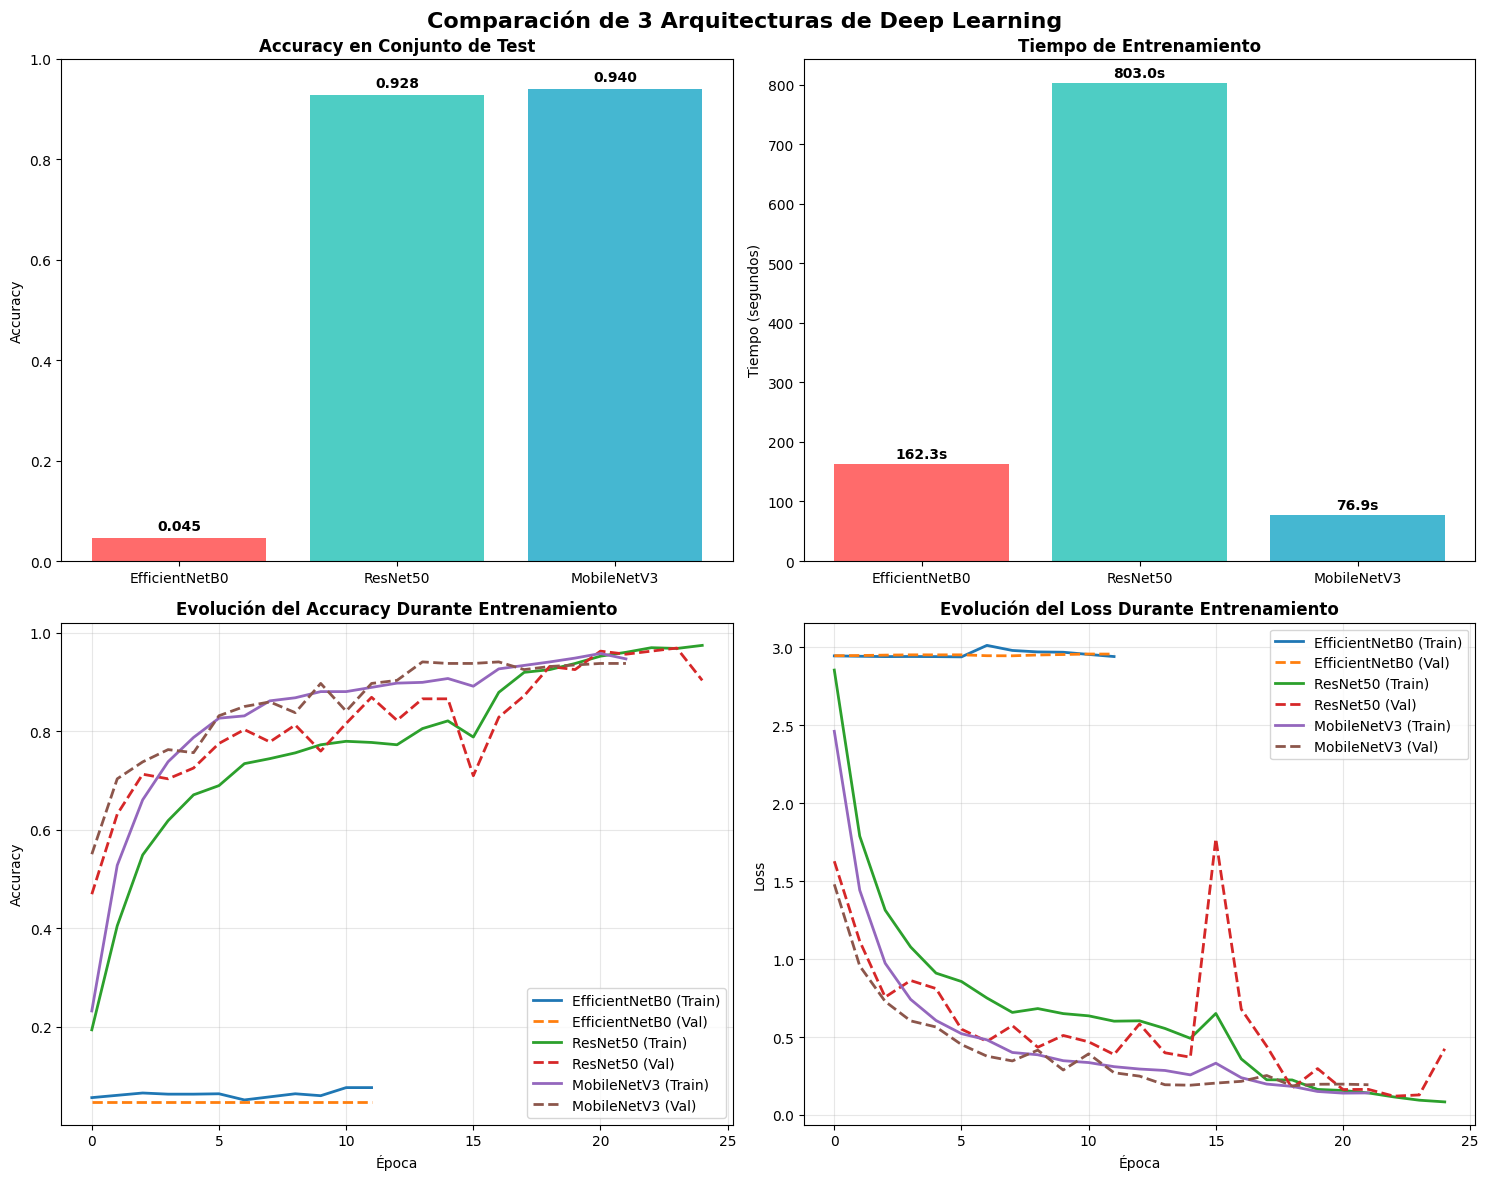

In [11]:
def create_comparison_plots(results, df_comparison):
    """Crea gráficas de comparación entre los modelos"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Comparación de 3 Arquitecturas de Deep Learning', fontsize=16, fontweight='bold')
    
    # 1. Accuracy comparativa
    ax1 = axes[0, 0]
    models = [r['model_name'] for r in results]
    test_accs = [r['final_test_acc'] for r in results]
    
    bars = ax1.bar(models, test_accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax1.set_title('Accuracy en Conjunto de Test', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    
    # Añadir valores en las barras
    for bar, acc in zip(bars, test_accs):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Tiempo de entrenamiento
    ax2 = axes[0, 1]
    times = [r['total_time'] for r in results]
    
    bars = ax2.bar(models, times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_title('Tiempo de Entrenamiento', fontweight='bold')
    ax2.set_ylabel('Tiempo (segundos)')
    
    # Añadir valores en las barras
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')
    
    # 3. Evolución del accuracy durante entrenamiento
    ax3 = axes[1, 0]
    for result in results:
        ax3.plot(result['history']['accuracy'], label=f"{result['model_name']} (Train)", linewidth=2)
        ax3.plot(result['history']['val_accuracy'], label=f"{result['model_name']} (Val)", linewidth=2, linestyle='--')
    
    ax3.set_title('Evolución del Accuracy Durante Entrenamiento', fontweight='bold')
    ax3.set_xlabel('Época')
    ax3.set_ylabel('Accuracy')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Evolución del loss durante entrenamiento
    ax4 = axes[1, 1]
    for result in results:
        ax4.plot(result['history']['loss'], label=f"{result['model_name']} (Train)", linewidth=2)
        ax4.plot(result['history']['val_loss'], label=f"{result['model_name']} (Val)", linewidth=2, linestyle='--')
    
    ax4.set_title('Evolución del Loss Durante Entrenamiento', fontweight='bold')
    ax4.set_xlabel('Época')
    ax4.set_ylabel('Loss')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Crear visualizaciones
create_comparison_plots(results, df_comparison)

In [12]:
print("RECOMENDACIONES FINALES")
print("=" * 60)

print(f"Arquitectura recomendada: {best_model['model_name']}")
print(f"Accuracy alcanzada: {best_model['final_test_acc']:.4f}")
print(f"Tiempo de entrenamiento: {best_model['total_time']:.2f} segundos")
print(f"Estado: Listo para implementación en tiempo real")

print(f"\nAnálisis de resultados:")
for result in results:
    status = "MEJOR" if result == best_model else "📊"
    print(f"   {status} {result['model_name']}: {result['final_test_acc']:.4f} accuracy")

RECOMENDACIONES FINALES
Arquitectura recomendada: MobileNetV3
Accuracy alcanzada: 0.9400
Tiempo de entrenamiento: 76.93 segundos
Estado: Listo para implementación en tiempo real

Análisis de resultados:
   📊 EfficientNetB0: 0.0450 accuracy
   📊 ResNet50: 0.9275 accuracy
   MEJOR MobileNetV3: 0.9400 accuracy
